In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/data/iot_training_data.csv"

# test read (only first few rows)
df = pd.read_csv(file_path, nrows=5)
print(df.head())

   5447  40  0  0.1  1  2  1767204000  3          0.2  2026-01-01 00:00:00  \
0  5888  45  0    0  1  2  1767204000  3     0.000000  2026-01-01 00:00:00   
1  6428  45  0    0  1  2  1767203926  2     0.000000  2026-01-01 00:00:00   
2  7258  27  9    0  2  1  1767182390  0     1.132264  2026-01-01 00:00:00   
3   253  27  7    0  2  2  1767055286  0  1425.677368  2026-01-01 00:00:00   
4   493  27  8    0  2  2  1766814818  0  1684.756348  2026-01-01 00:00:00   

   2025-12-31 23:59:57  
0  2025-12-31 23:59:57  
1  2025-12-31 23:59:57  
2  2025-12-31 23:59:52  
3  2025-12-31 23:59:57  
4  2025-12-31 23:59:52  


In [ ]:
print(first_chunk.isnull().sum())

RmsStationId     0
NodeId           0
TenantId         0
TagId            0
LogType          0
LogSubType       0
MobileNumber     0
LogIntValue      0
LogFloatValue    0
ServerTime       0
LogTime          0
dtype: int64


In [ ]:
print(first_chunk[['LogIntValue', 'LogFloatValue']].head())

   LogIntValue  LogFloatValue
0            3       0.000000
1            3       0.000000
2            2       0.000000
3            0       1.132264
4            0    1425.677368


In [ ]:
first_chunk[['LogIntValue', 'LogFloatValue']].describe()

,LogIntValue,LogFloatValue
count,100000.000000,100000.000000
mean,0.657550,395.509333
std,1.129208,890.969915
min,0.000000,0.000000
25%,0.000000,0.003227
50%,0.000000,22.734434
75%,2.000000,53.953087
max,3.000000,6758.000000


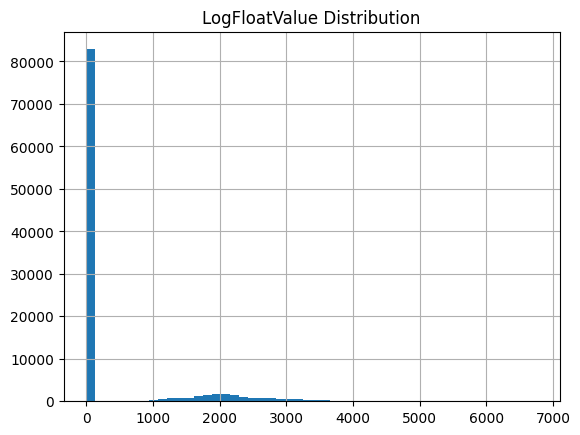

In [ ]:
import matplotlib.pyplot as plt

first_chunk['LogFloatValue'].hist(bins=50)
plt.title("LogFloatValue Distribution")
plt.show()

In [ ]:
first_chunk['LogType'].value_counts().head()

,count
LogType,
2,65811
6,8932
5,8920
4,8919
1,7418


In [ ]:
first_chunk.isnull().sum()

,0
RmsStationId,0
NodeId,0
TenantId,0
TagId,0
LogType,0
LogSubType,0
MobileNumber,0
LogIntValue,0
LogFloatValue,0
ServerTime,0


In [ ]:
names=columns,
header=None

In [ ]:
import pandas as pd
import numpy as np

# =========================
# CONFIG
# =========================
file_path = "/content/drive/MyDrive/data/iot_training_data.csv"

columns = [
    "RmsStationId",
    "NodeId",
    "TenantId",
    "TagId",
    "LogType",
    "LogSubType",
    "MobileNumber",
    "LogIntValue",
    "LogFloatValue",
    "ServerTime",
    "LogTime"
]

chunksize = 500000

# storage
all_chunks = []

# =========================
# STEP 1: READ IN CHUNKS
# =========================
for i, chunk in enumerate(pd.read_csv(file_path, names=columns, header=None, chunksize=chunksize)):
    print(f"Reading chunk {i}")
    all_chunks.append(chunk)

    # limit reading to avoid overload (adjust if needed)
    if i == 10:
        break

df = pd.concat(all_chunks)
print("Total loaded:", df.shape)

# =========================
# STEP 2: SHUFFLE DATA
# =========================
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# =========================
# STEP 3: SPLIT DATASETS
# =========================

# ---- TRAIN (NO LABELS, NO ANOMALIES) ----
train_df = df.iloc[:500000].copy()

# ---- TEST (FOR EVALUATION) ----
test_df = df.iloc[500000:600000].copy()

# create ground truth labels (0 = normal)
test_df["true_label"] = 0

# inject anomalies (5%)
n_anomaly = int(0.05 * len(test_df))
idx = np.random.choice(test_df.index, n_anomaly, replace=False)

test_df.loc[idx, "LogFloatValue"] *= 10
test_df.loc[idx, "true_label"] = 1

# ---- LIVE (FOR FRONTEND DEMO) ----
live_df = df.iloc[600000:650000].copy()

# =========================
# STEP 4: SAVE FILES
# =========================

train_df.to_csv("/content/train.csv", index=False)
test_df.to_csv("/content/test.csv", index=False)
live_df.to_csv("/content/live.csv", index=False)

print("All datasets created successfully!")

Reading chunk 0
Reading chunk 1
Reading chunk 2
Reading chunk 3
Reading chunk 4
Reading chunk 5
Reading chunk 6
Reading chunk 7
Reading chunk 8
Reading chunk 9
Reading chunk 10
Total loaded: (5500000, 11)
All datasets created successfully!


In [ ]:
from google.colab import files

files.download("/content/train.csv")
files.download("/content/test.csv")
files.download("/content/live.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

train_df = pd.read_csv("/content/train.csv")
test_df = pd.read_csv("/content/test.csv")
live_df = pd.read_csv("/content/live.csv")

In [ ]:
for df in [train_df, test_df, live_df]:
    df['LogTime'] = pd.to_datetime(df['LogTime'])
    df['ServerTime'] = pd.to_datetime(df['ServerTime'])

In [ ]:
def add_time_features(df):
    df['log_hour'] = df['LogTime'].dt.hour
    df['log_dayofweek'] = df['LogTime'].dt.dayofweek
    df['is_night'] = df['log_hour'].apply(lambda x: 1 if x < 6 or x > 22 else 0)
    df['time_delay_sec'] = (df['ServerTime'] - df['LogTime']).dt.total_seconds()
    return df

train_df = add_time_features(train_df)
test_df = add_time_features(test_df)
live_df = add_time_features(live_df)

In [ ]:
for df in [train_df, test_df, live_df]:
    df.replace([float('inf'), -float('inf')], 0, inplace=True)
    df.fillna(0, inplace=True)

In [ ]:
train_df.to_csv("/content/train_updated.csv", index=False)
test_df.to_csv("/content/test_updated.csv", index=False)
live_df.to_csv("/content/live_updated.csv", index=False)

In [ ]:
from google.colab import files

files.download("/content/train_updated.csv")
files.download("/content/test_updated.csv")
files.download("/content/live_updated.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("/content/live_updated.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
train_df = pd.read_csv("/content/train_updated.csv")
test_df  = pd.read_csv("/content/test_updated.csv")
live_df  = pd.read_csv("/content/live_updated.csv")

In [ ]:
combined = pd.concat(
    [train_df, test_df, live_df],
    keys=["train", "test", "live"]
)

combined = pd.get_dummies(
    combined,
    columns=["LogType", "LogSubType"]
)

In [ ]:
train_df = combined.xs("train")
test_df  = combined.xs("test")
live_df  = combined.xs("live")

In [ ]:
train_df.to_csv("/content/train_data.csv", index=False)
test_df.to_csv("/content/test_data.csv", index=False)
live_df.to_csv("/content/live_data.csv", index=False)

In [ ]:
from google.colab import files

files.download("/content/train_data.csv")
files.download("/content/test_data.csv")
files.download("/content/live_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download("/content/train_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df = pd.get_dummies(df, columns=["LogTypeID", "LogSubTypeID"])

KeyError: "None of [Index(['LogTypeID', 'LogSubTypeID'], dtype='object')] are in the [columns]"

In [ ]:
print(df.columns)

Index(['RmsStationId', 'NodeId', 'TenantId', 'TagId', 'LogType', 'LogSubType',
       'MobileNumber', 'LogIntValue', 'LogFloatValue', 'ServerTime', 'LogTime',
       'log_hour', 'log_dayofweek', 'is_night', 'time_delay_sec'],
      dtype='object')


In [ ]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.05)
model.fit(first_chunk[['LogIntValue', 'LogFloatValue']])

pred = model.predict(first_chunk[['LogIntValue', 'LogFloatValue']])

first_chunk['anomaly'] = pred
print(first_chunk.head())

   RmsStationId  NodeId  TenantId  TagId  LogType  LogSubType  MobileNumber  \
0          5447      40         0      0        1           2    1767204000   
1          5888      45         0      0        1           2    1767204000   
2          6428      45         0      0        1           2    1767203926   
3          7258      27         9      0        2           1    1767182390   
4           253      27         7      0        2           2    1767055286   

   LogIntValue  LogFloatValue           ServerTime              LogTime  \
0            3       0.000000  2026-01-01 00:00:00  2025-12-31 23:59:57   
1            3       0.000000  2026-01-01 00:00:00  2025-12-31 23:59:57   
2            2       0.000000  2026-01-01 00:00:00  2025-12-31 23:59:57   
3            0       1.132264  2026-01-01 00:00:00  2025-12-31 23:59:52   
4            0    1425.677368  2026-01-01 00:00:00  2025-12-31 23:59:57   

   anomaly  
0        1  
1        1  
2        1  
3        1  
4        

In [ ]:
chunk = pd.read_csv(file_path, names=columns, header=None, chunksize=100000)

first_chunk = next(chunk)

print(first_chunk.head())
print(first_chunk.shape)

   RmsStationId  NodeId  TenantId  TagId  LogType  LogSubType  MobileNumber  \
0          5447      40         0      0        1           2    1767204000   
1          5888      45         0      0        1           2    1767204000   
2          6428      45         0      0        1           2    1767203926   
3          7258      27         9      0        2           1    1767182390   
4           253      27         7      0        2           2    1767055286   

   LogIntValue  LogFloatValue           ServerTime              LogTime  
0            3       0.000000  2026-01-01 00:00:00  2025-12-31 23:59:57  
1            3       0.000000  2026-01-01 00:00:00  2025-12-31 23:59:57  
2            2       0.000000  2026-01-01 00:00:00  2025-12-31 23:59:57  
3            0       1.132264  2026-01-01 00:00:00  2025-12-31 23:59:52  
4            0    1425.677368  2026-01-01 00:00:00  2025-12-31 23:59:57  
(100000, 11)


In [ ]:
print(df.columns)

Index(['RmsStationId', 'NodeId', 'TenantId', 'TagId', 'LogType', 'LogSubType',
       'MobileNumber', 'LogIntValue', 'LogFloatValue', 'ServerTime',
       'LogTime'],
      dtype='object')


In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/data/iot_training_data.csv"

columns = [
    "RmsStationId",
    "NodeId",
    "TenantId",
    "TagId",
    "LogType",
    "LogSubType",
    "MobileNumber",
    "LogIntValue",
    "LogFloatValue",
    "ServerTime",
    "LogTime"
]

df = pd.read_csv(file_path, names=columns, header=None, nrows=5)

print(df.head())

   RmsStationId  NodeId  TenantId  TagId  LogType  LogSubType  MobileNumber  \
0          5447      40         0      0        1           2    1767204000   
1          5888      45         0      0        1           2    1767204000   
2          6428      45         0      0        1           2    1767203926   
3          7258      27         9      0        2           1    1767182390   
4           253      27         7      0        2           2    1767055286   

   LogIntValue  LogFloatValue           ServerTime              LogTime  
0            3       0.000000  2026-01-01 00:00:00  2025-12-31 23:59:57  
1            3       0.000000  2026-01-01 00:00:00  2025-12-31 23:59:57  
2            2       0.000000  2026-01-01 00:00:00  2025-12-31 23:59:57  
3            0       1.132264  2026-01-01 00:00:00  2025-12-31 23:59:52  
4            0    1425.677368  2026-01-01 00:00:00  2025-12-31 23:59:57  


In [1]:
import os

print(os.listdir('/content'))

['.config', 'sample_data']


In [3]:
import pandas as pd

train_df = pd.read_csv("/content/train_data.csv")
test_df  = pd.read_csv("/content/test_data.csv")
live_df  = pd.read_csv("/content/live_data.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/content/train_data.csv'